# EDA_REAL - Phan bo du lieu thuc te theo lop

Notebook nay mo ta tap du lieu thuc te trong `DataSet/DataRealTest`, sau do tach du lieu theo ty le **80/10/10** thanh `train_real`, `real_val` va `real_test`.

Muc tieu:
- `train_real`: du lieu thuc te co the dung de fine-tuning.
- `real_val`: du lieu thuc te dung de theo doi/chon checkpoint.
- `real_test`: du lieu thuc te doc lap, chi dung de danh gia cuoi cung gan production.

Notebook nay khong copy anh sang thu muc moi; no chi tinh toan split bang seed co dinh va hien thi thong ke/visualization de phuc vu bao cao.


In [1]:
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")

SOURCE_DIR = Path("DataSet/DataRealTest")

# Split production-style: train/validation/test = 80/10/10 theo tung lop.
TRAIN_RATIO = 0.80
REAL_VAL_RATIO = 0.10
REAL_TEST_RATIO = 0.10
RANDOM_SEED = 42

CLASSES = [
    "Battery",
    "Biological",
    "General_Waste",
    "Glass",
    "Metal",
    "Paper_Cardboard",
    "Plastic",
]

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}


In [2]:
def list_image_files(class_dir: Path) -> list[Path]:
    return sorted(
        image_path
        for image_path in class_dir.rglob("*")
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS
    )


def load_real_samples(source_dir: Path) -> tuple[list[tuple[Path, str]], dict[str, int]]:
    if not source_dir.exists():
        raise FileNotFoundError(f"Khong tim thay thu muc dataset: {source_dir}")

    samples = []
    class_counts = {}

    for class_name in CLASSES:
        class_dir = source_dir / class_name
        images = list_image_files(class_dir) if class_dir.exists() else []
        class_counts[class_name] = len(images)
        samples.extend((image_path, class_name) for image_path in images)

    return samples, class_counts


def split_real_train_val_test(
    samples: list[tuple[Path, str]],
    val_ratio: float = 0.10,
    test_ratio: float = 0.10,
    seed: int = 42,
) -> tuple[list[tuple[Path, str]], list[tuple[Path, str]], list[tuple[Path, str]]]:
    # Tach theo tung lop de val/test deu co dai dien cua moi class.
    import numpy as np

    rng = np.random.RandomState(seed)
    by_class = defaultdict(list)
    for sample in samples:
        by_class[sample[1]].append(sample)

    train_real = []
    real_val = []
    real_test = []

    for class_name in CLASSES:
        class_samples = by_class.get(class_name, [])
        if not class_samples:
            continue

        indices = rng.permutation(len(class_samples))
        shuffled = [class_samples[index] for index in indices]

        if len(shuffled) >= 3:
            test_count = max(1, round(len(shuffled) * test_ratio))
            val_count = max(1, round(len(shuffled) * val_ratio))
        elif len(shuffled) == 2:
            test_count = 1
            val_count = 0
        else:
            test_count = 0
            val_count = 0

        # Dam bao con it nhat 1 anh train neu class co du lieu.
        overflow = max(0, test_count + val_count - (len(shuffled) - 1))
        if overflow:
            reduce_val = min(val_count, overflow)
            val_count -= reduce_val
            overflow -= reduce_val
            test_count = max(0, test_count - overflow)

        test_items = shuffled[:test_count]
        val_items = shuffled[test_count:test_count + val_count]
        train_items = shuffled[test_count + val_count:]

        real_test.extend(test_items)
        real_val.extend(val_items)
        train_real.extend(train_items)

    rng.shuffle(train_real)
    rng.shuffle(real_val)
    rng.shuffle(real_test)
    return train_real, real_val, real_test


def count_by_class(samples: list[tuple[Path, str]]) -> dict[str, int]:
    counts = {class_name: 0 for class_name in CLASSES}
    for _, class_name in samples:
        counts[class_name] += 1
    return counts


real_samples, total_counts = load_real_samples(SOURCE_DIR)
train_real_samples, real_val_samples, real_test_samples = split_real_train_val_test(
    real_samples,
    val_ratio=REAL_VAL_RATIO,
    test_ratio=REAL_TEST_RATIO,
    seed=RANDOM_SEED,
)

train_counts = count_by_class(train_real_samples)
real_val_counts = count_by_class(real_val_samples)
real_test_counts = count_by_class(real_test_samples)

summary_rows = []
for class_name in CLASSES:
    total_count = total_counts[class_name]
    train_count = train_counts[class_name]
    val_count = real_val_counts[class_name]
    test_count = real_test_counts[class_name]
    summary_rows.append(
        {
            "class_name": class_name,
            "total_count": total_count,
            "train_real_count": train_count,
            "real_val_count": val_count,
            "real_test_count": test_count,
        }
    )

summary_rows = sorted(summary_rows, key=lambda row: row["total_count"], reverse=True)
summary_rows


[{'class_name': 'Battery',
  'total_count': 384,
  'train_real_count': 308,
  'real_val_count': 38,
  'real_test_count': 38},
 {'class_name': 'Paper_Cardboard',
  'total_count': 214,
  'train_real_count': 172,
  'real_val_count': 21,
  'real_test_count': 21},
 {'class_name': 'Plastic',
  'total_count': 198,
  'train_real_count': 158,
  'real_val_count': 20,
  'real_test_count': 20},
 {'class_name': 'General_Waste',
  'total_count': 149,
  'train_real_count': 119,
  'real_val_count': 15,
  'real_test_count': 15},
 {'class_name': 'Metal',
  'total_count': 128,
  'train_real_count': 102,
  'real_val_count': 13,
  'real_test_count': 13},
 {'class_name': 'Biological',
  'total_count': 60,
  'train_real_count': 48,
  'real_val_count': 6,
  'real_test_count': 6},
 {'class_name': 'Glass',
  'total_count': 25,
  'train_real_count': 21,
  'real_val_count': 2,
  'real_test_count': 2}]

In [3]:
total_train_real = sum(row["train_real_count"] for row in summary_rows)
total_real_val = sum(row["real_val_count"] for row in summary_rows)
total_real_test = sum(row["real_test_count"] for row in summary_rows)
total_images = sum(row["total_count"] for row in summary_rows)
non_zero_counts = [row["total_count"] for row in summary_rows if row["total_count"] > 0]
imbalance_ratio = max(non_zero_counts) / min(non_zero_counts) if non_zero_counts else 0

summary_lines = [
    f"**Tong anh real:** {total_images:,} | **Train real:** {total_train_real:,} "
    f"({total_train_real / total_images * 100:.2f}%) | **Real val:** {total_real_val:,} "
    f"({total_real_val / total_images * 100:.2f}%) | **Real test:** {total_real_test:,} "
    f"({total_real_test / total_images * 100:.2f}%)",
    f"**Imbalance ratio:** {imbalance_ratio:.2f}x | **Seed:** {RANDOM_SEED} | "
    f"**Target split:** {TRAIN_RATIO:.0%}/{REAL_VAL_RATIO:.0%}/{REAL_TEST_RATIO:.0%}",
    "",
    "| Lop du lieu | Train real | Real val | Real test | Tong | Val (%) | Test (%) |",
    "|---|---:|---:|---:|---:|---:|---:|",
]

for row in summary_rows:
    total_count = row["total_count"]
    val_percent = row["real_val_count"] / total_count * 100 if total_count else 0
    test_percent = row["real_test_count"] / total_count * 100 if total_count else 0

    summary_lines.append(
        f"| {row['class_name']} | {row['train_real_count']} | {row['real_val_count']} | "
        f"{row['real_test_count']} | {total_count} | {val_percent:.2f} | {test_percent:.2f} |"
    )

summary_lines.extend(
    [
        "",
        "Ghi chu: split duoc tach theo tung lop de `real_val` va `real_test` deu co dai dien cua moi class. "
        "Do so luong anh moi lop khong chia het cho 10%, ty le thuc te se xap xi 80/10/10.",
    ]
)

display(Markdown("\n".join(summary_lines)))


**Tong anh real:** 1,158 | **Train real:** 928 (80.14%) | **Real val:** 115 (9.93%) | **Real test:** 115 (9.93%)
**Imbalance ratio:** 15.36x | **Seed:** 42 | **Target split:** 80%/10%/10%

| Lop du lieu | Train real | Real val | Real test | Tong | Val (%) | Test (%) |
|---|---:|---:|---:|---:|---:|---:|
| Battery | 308 | 38 | 38 | 384 | 9.90 | 9.90 |
| Paper_Cardboard | 172 | 21 | 21 | 214 | 9.81 | 9.81 |
| Plastic | 158 | 20 | 20 | 198 | 10.10 | 10.10 |
| General_Waste | 119 | 15 | 15 | 149 | 10.07 | 10.07 |
| Metal | 102 | 13 | 13 | 128 | 10.16 | 10.16 |
| Biological | 48 | 6 | 6 | 60 | 10.00 | 10.00 |
| Glass | 21 | 2 | 2 | 25 | 8.00 | 8.00 |

Ghi chu: split duoc tach theo tung lop de `real_val` va `real_test` deu co dai dien cua moi class. Do so luong anh moi lop khong chia het cho 10%, ty le thuc te se xap xi 80/10/10.

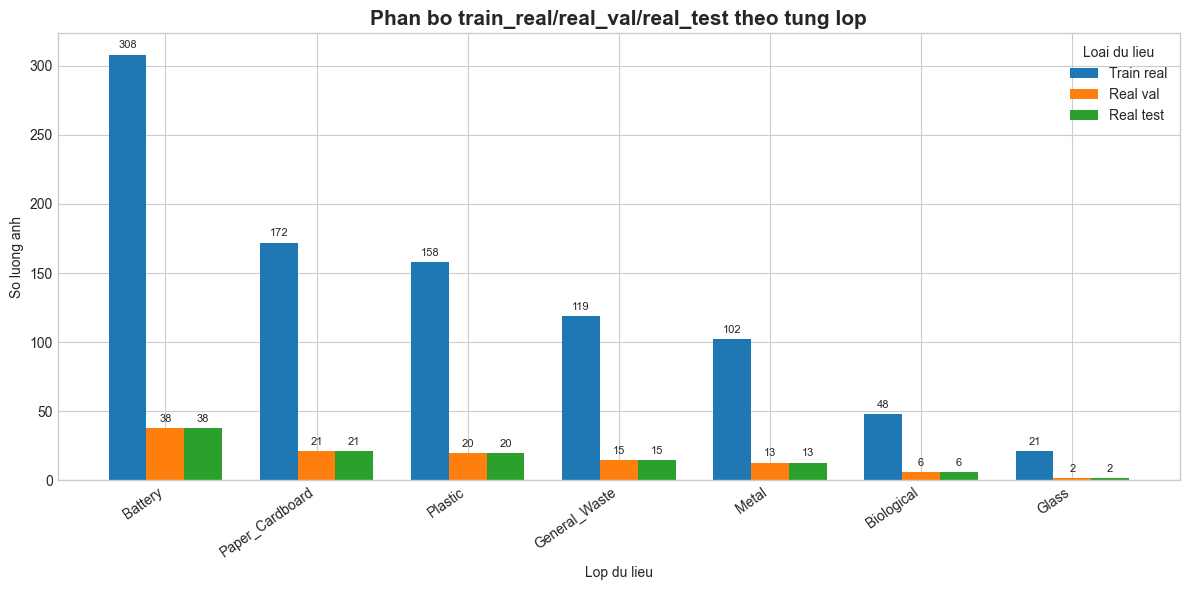

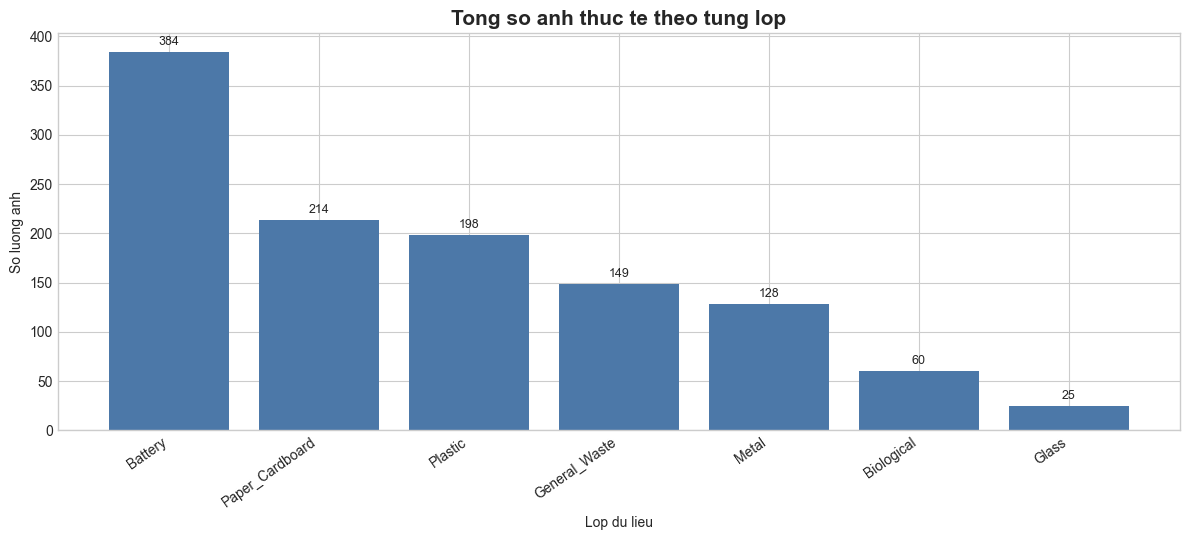

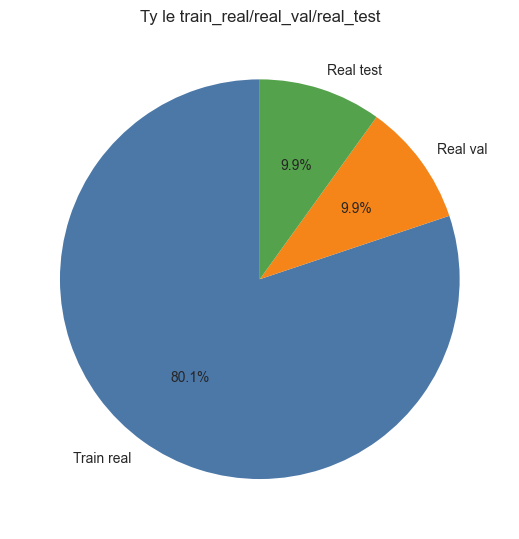

In [4]:
classes = [row["class_name"] for row in summary_rows]
train_values = [row["train_real_count"] for row in summary_rows]
real_val_values = [row["real_val_count"] for row in summary_rows]
real_test_values = [row["real_test_count"] for row in summary_rows]
total_values = [row["total_count"] for row in summary_rows]
x_positions = list(range(len(classes)))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
train_bars = ax.bar([x - bar_width for x in x_positions], train_values, width=bar_width, label="Train real")
real_val_bars = ax.bar(x_positions, real_val_values, width=bar_width, label="Real val")
real_test_bars = ax.bar([x + bar_width for x in x_positions], real_test_values, width=bar_width, label="Real test")

ax.set_title("Phan bo train_real/real_val/real_test theo tung lop", fontsize=15, fontweight="bold")
ax.set_xlabel("Lop du lieu")
ax.set_ylabel("So luong anh")
ax.set_xticks(x_positions)
ax.set_xticklabels(classes, rotation=35, ha="right")
ax.legend(title="Loai du lieu")
ax.bar_label(train_bars, padding=3, fontsize=8)
ax.bar_label(real_val_bars, padding=3, fontsize=8)
ax.bar_label(real_test_bars, padding=3, fontsize=8)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5.5))
total_bars = ax.bar(classes, total_values, color="#4C78A8")
ax.set_title("Tong so anh thuc te theo tung lop", fontsize=15, fontweight="bold")
ax.set_xlabel("Lop du lieu")
ax.set_ylabel("So luong anh")
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=35, ha="right")
ax.bar_label(total_bars, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.pie(
    [total_train_real, total_real_val, total_real_test],
    labels=["Train real", "Real val", "Real test"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C78A8", "#F58518", "#54A24B"],
)
ax.set_title("Ty le train_real/real_val/real_test")
plt.tight_layout()
plt.show()


In [5]:
from PIL import Image, UnidentifiedImageError

image_stats = []
invalid_images = []

for image_path, class_name in real_samples:
    try:
        with Image.open(image_path) as image:
            width, height = image.size
    except (OSError, UnidentifiedImageError) as exc:
        invalid_images.append((image_path, class_name, str(exc)))
        continue

    image_stats.append(
        {
            "class_name": class_name,
            "width": width,
            "height": height,
            "aspect_ratio": width / height if height else 0,
        }
    )

stat_lines = [
    f"**Anh doc duoc:** {len(image_stats):,} | **Anh loi:** {len(invalid_images):,}",
    "",
    "| Lop du lieu | Min WxH | Median WxH | Max WxH | Median aspect ratio |",
    "|---|---:|---:|---:|---:|",
]

for class_name in CLASSES:
    rows = [row for row in image_stats if row["class_name"] == class_name]
    if not rows:
        stat_lines.append(f"| {class_name} | - | - | - | - |")
        continue

    widths = sorted(row["width"] for row in rows)
    heights = sorted(row["height"] for row in rows)
    areas = [row["width"] * row["height"] for row in rows]
    min_row = rows[areas.index(min(areas))]
    max_row = rows[areas.index(max(areas))]
    mid = len(rows) // 2
    median_width = widths[mid]
    median_height = heights[mid]
    median_aspect = sorted(row["aspect_ratio"] for row in rows)[mid]

    stat_lines.append(
        f"| {class_name} | {min_row['width']}x{min_row['height']} | "
        f"{median_width}x{median_height} | {max_row['width']}x{max_row['height']} | {median_aspect:.2f} |"
    )

if invalid_images:
    stat_lines.extend(["", "**Anh loi:**"])
    for image_path, class_name, error in invalid_images[:10]:
        stat_lines.append(f"- `{image_path}` ({class_name}): {error}")

display(Markdown("\n".join(stat_lines)))


**Anh doc duoc:** 1,158 | **Anh loi:** 0

| Lop du lieu | Min WxH | Median WxH | Max WxH | Median aspect ratio |
|---|---:|---:|---:|---:|
| Battery | 54x114 | 268x251 | 4032x3024 | 1.00 |
| Biological | 120x120 | 275x275 | 480x480 | 1.00 |
| General_Waste | 121x121 | 480x480 | 1538x2048 | 1.00 |
| Glass | 131x131 | 324x324 | 480x480 | 1.00 |
| Metal | 126x126 | 387x338 | 2160x2700 | 1.00 |
| Paper_Cardboard | 123x123 | 360x375 | 1920x1920 | 1.00 |
| Plastic | 128x128 | 500x589 | 961x1280 | 1.00 |

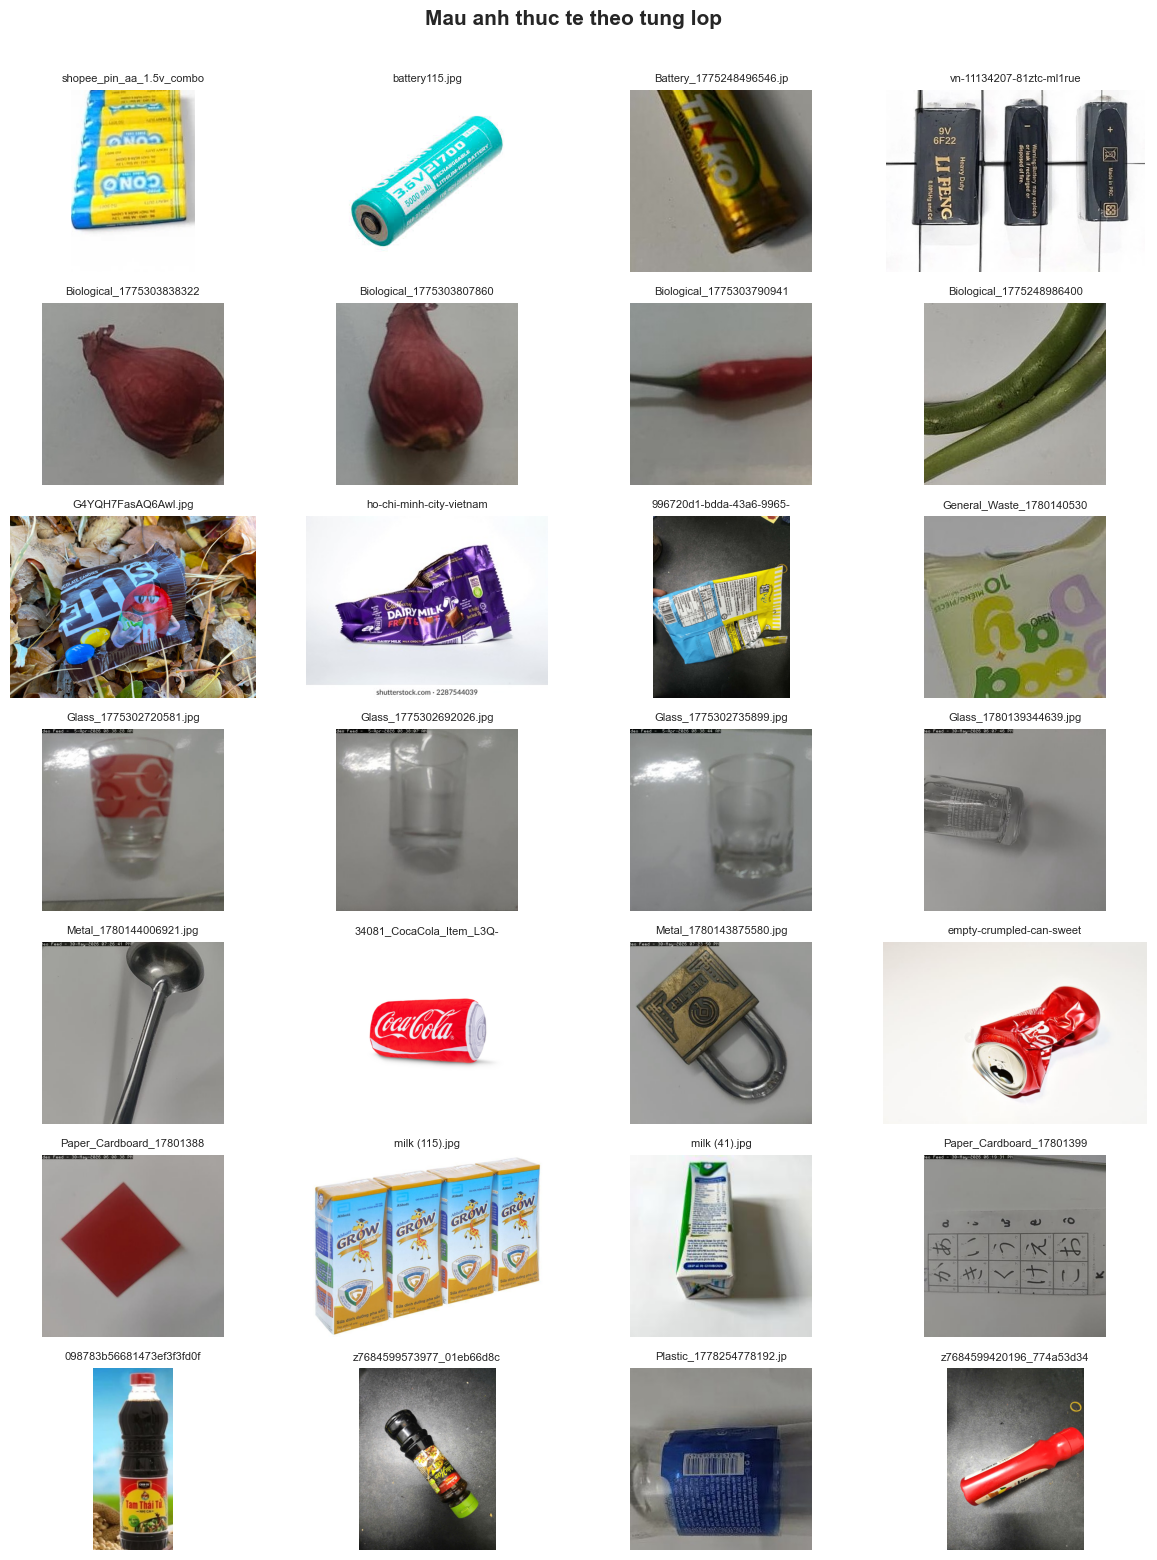

In [6]:
import random
from PIL import Image

samples_per_class = 4
rng = random.Random(RANDOM_SEED)
fig, axes = plt.subplots(len(CLASSES), samples_per_class, figsize=(12, 2.2 * len(CLASSES)))

for row_index, class_name in enumerate(CLASSES):
    class_images = [image_path for image_path, label in real_samples if label == class_name]
    selected_images = rng.sample(class_images, min(samples_per_class, len(class_images))) if class_images else []

    for col_index in range(samples_per_class):
        ax = axes[row_index, col_index]
        ax.axis("off")

        if col_index >= len(selected_images):
            continue

        image_path = selected_images[col_index]
        with Image.open(image_path) as image:
            ax.imshow(image.convert("RGB"))
        if col_index == 0:
            ax.set_ylabel(class_name, fontsize=11, fontweight="bold")
        ax.set_title(image_path.name[:24], fontsize=8)

fig.suptitle("Mau anh thuc te theo tung lop", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
